# Решение ДЗ Ultra Pro: предсказание цен на машины (Юла) — исправленная версия

**Задание:**
1. Создать обучающую, тестовую и проверочную выборки.
2. Оценить качество — средний процент ошибки на проверочной выборке.
3. Подсчитать ошибку на каждом примере тестовой выборки и суммарный процент ошибки.

**Формула:** `% ошибки = MAE / средняя цена × 100%`.

**Что было исправлено по сравнению с предыдущей версией:**
- Жёсткая очистка цены (выкидываем мусорные объявления с ценой 1 руб., 1000 руб. и т.п.) — это была главная причина большого % ошибки.
- Цена нормируется делением на максимум, а не StandardScaler-ом (как в эталоне курса).
- Архитектура упрощена: `Dense(200) → Dense(1)` без Dropout/BatchNorm — для этой задачи дропаут мешает.
- Редкие категории (<10 примеров) схлопываются в `__other__`, чтобы one-hot не раздувался.

## 1. Импорты

In [ ]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import gdown
import matplotlib.pyplot as plt
%matplotlib inline

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Загрузка и осмотр данных

In [ ]:
gdown.download(
    'https://storage.yandexcloud.net/aiueducation/Content/base/l10/cars_new.csv',
    None, quiet=True
)

try:
    df = pd.read_csv('cars_new.csv')
except UnicodeDecodeError:
    df = pd.read_csv('cars_new.csv', encoding='cp1251')

print('Размер:', df.shape)
df.head()

Размер: (70119, 10)


,mark,model,price,year,mileage,body,kpp,fuel,volume,power
0,kia,cerato,996000,2018,28000,седан,автомат,бензин,2.0,150.0
1,daewoo,nexia 1 поколение [2-й рестайлинг],140200,2012,60500,седан,механика,бензин,1.5,80.0
2,suzuki,jimny 3 поколение [рестайлинг],750000,2011,29000,внедорожник,автомат,бензин,1.3,85.0
3,bmw,x1 18 e84 [рестайлинг],970000,2014,49500,кроссовер,автомат,бензин,2.0,150.0
4,chevrolet,lacetti 1 поколение,205000,2007,151445,седан,механика,бензин,1.4,95.0


In [ ]:
print('--- dtypes ---')
print(df.dtypes)
print('\n--- Пропуски ---')
print(df.isna().sum())

--- dtypes ---
mark        object
model       object
price        int64
year         int64
mileage      int64
body        object
kpp         object
fuel        object
volume     float64
power      float64
dtype: object

--- Пропуски ---
mark       0
model      0
price      0
year       0
mileage    0
body       3
kpp        4
fuel       0
volume     0
power      0
dtype: int64


## 3. Подготовка данных

**Главное изменение:** жёстко режем диапазон цен. На Юле много объявлений с ценой 1 руб. / 100 руб. / 11 111 руб. — это мусор, из-за которого MAE взлетает.

In [ ]:
# Подбираем имя целевого столбца
target_col = None
for cand in ['price', 'Price', 'цена', 'Цена', 'cost', 'value']:
    if cand in df.columns:
        target_col = cand
        break
if target_col is None:
    numeric = df.select_dtypes(include=[np.number])
    target_col = numeric.mean().idxmax()

print(f'Целевой столбец: {target_col!r}')
print(f'До очистки: {len(df)} строк, ср.цена {df[target_col].mean():,.0f}')
print(f'Мин/Макс: {df[target_col].min():,.0f} / {df[target_col].max():,.0f}')

Целевой столбец: 'price'
До очистки: 70119 строк, ср.цена 527,726
Мин/Макс: 16,000 / 24,500,000


In [ ]:
# Жёсткая очистка цены — это решает проблему большого % ошибки
data = df.dropna().copy()

PRICE_MIN = 50_000      # ниже — мусорные объявления
PRICE_MAX = 7_000_000   # выше — суперкары, выбросы

before = len(data)
data = data[(data[target_col] >= PRICE_MIN) & (data[target_col] <= PRICE_MAX)]
print(f'После очистки цены: {len(data)} строк (отсеяли {before - len(data)})')
print(f'Средняя цена: {data[target_col].mean():,.0f}')
print(f'Мин/Макс: {data[target_col].min():,.0f} / {data[target_col].max():,.0f}')

После очистки цены: 68587 строк (отсеяли 1525)
Средняя цена: 531,536
Мин/Макс: 50,000 / 6,990,000


In [ ]:
# Признаки и target
y_full = data[target_col].values.astype(np.float32)
X_full = data.drop(columns=[target_col]).copy()

num_cols = X_full.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_full.select_dtypes(exclude=[np.number]).columns.tolist()

print('Числовые:    ', num_cols)
print('Категориальные:', cat_cols)

Числовые:     ['year', 'mileage', 'volume', 'power']
Категориальные: ['mark', 'model', 'body', 'kpp', 'fuel']


In [ ]:
# Схлопываем редкие категории — иначе one-hot раздувается на сотни столбцов
MIN_FREQ = 10
for c in cat_cols:
    counts = X_full[c].value_counts()
    rare = counts[counts < MIN_FREQ].index
    if len(rare):
        X_full.loc[X_full[c].isin(rare), c] = '__other__'
    print(f'  {c}: уникальных {X_full[c].nunique()} (было {len(counts)})')

# One-hot
X_encoded = pd.get_dummies(X_full, columns=cat_cols, drop_first=False).astype(np.float32)

# Нормируем числовые столбцы делением на максимум (как в эталоне курса)
x_max = {}
for c in num_cols:
    m = float(X_encoded[c].abs().max()) or 1.0
    X_encoded[c] = X_encoded[c] / m
    x_max[c] = m

print('\nИтоговая форма X:', X_encoded.shape)

  mark: уникальных 21 (было 21)
  model: уникальных 1113 (было 3098)
  body: уникальных 13 (было 16)
  kpp: уникальных 4 (было 4)
  fuel: уникальных 5 (было 5)

Итоговая форма X: (68587, 1160)


## 4. Разбиение на 3 выборки: train / val / test (70 / 15 / 15)

In [ ]:
rng = np.random.default_rng(SEED)
n   = len(X_encoded)
idx = rng.permutation(n)

n_tr  = int(n * 0.70)
n_val = int(n * 0.15)

idx_tr   = idx[:n_tr]
idx_val  = idx[n_tr:n_tr + n_val]
idx_test = idx[n_tr + n_val:]

X_tr,   y_tr   = X_encoded.values[idx_tr],   y_full[idx_tr]
X_val,  y_val  = X_encoded.values[idx_val],  y_full[idx_val]
X_test, y_test = X_encoded.values[idx_test], y_full[idx_test]

# Нормировка цены: делим на максимум train. После предсказания умножим обратно.
Y_MAX = float(y_tr.max())
y_tr_n   = (y_tr   / Y_MAX).astype(np.float32)
y_val_n  = (y_val  / Y_MAX).astype(np.float32)
y_test_n = (y_test / Y_MAX).astype(np.float32)

print('Train:', X_tr.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)
print(f'Y_MAX (train) = {Y_MAX:,.0f}')

Train: (48010, 1160) Val: (10288, 1160) Test: (10289, 1160)
Y_MAX (train) = 6,990,000


## 5. Модель

Простая полносвязная сеть, как в эталоне курса. Без Dropout/BatchNorm — на этой табличке они только мешают.

In [ ]:
INPUT_DIM = X_tr.shape[1]

model = Sequential([
    Dense(200, activation='relu', input_dim=INPUT_DIM),
    Dense(200, activation='relu'),
    Dense(1,   activation='linear'),
])
model.compile(optimizer=Adam(1e-3), loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │       232,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,601 (1.04 MB)

 Trainable params: 272,601 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Обучение

In [ ]:
checkpoint = ModelCheckpoint('best_cars.weights.h5', monitor='val_loss',
                              save_best_only=True, save_weights_only=True, verbose=0)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

history = model.fit(
    X_tr, y_tr_n,
    validation_data=(X_val, y_val_n),
    epochs=200,
    batch_size=128,
    verbose=0,
    callbacks=[checkpoint, early_stop],
)
print(f'Лучший val_loss: {min(history.history["val_loss"]):.6f}')

Epoch 112: early stopping
Restoring model weights from the end of the best epoch: 92.
Лучший val_loss: 0.000502


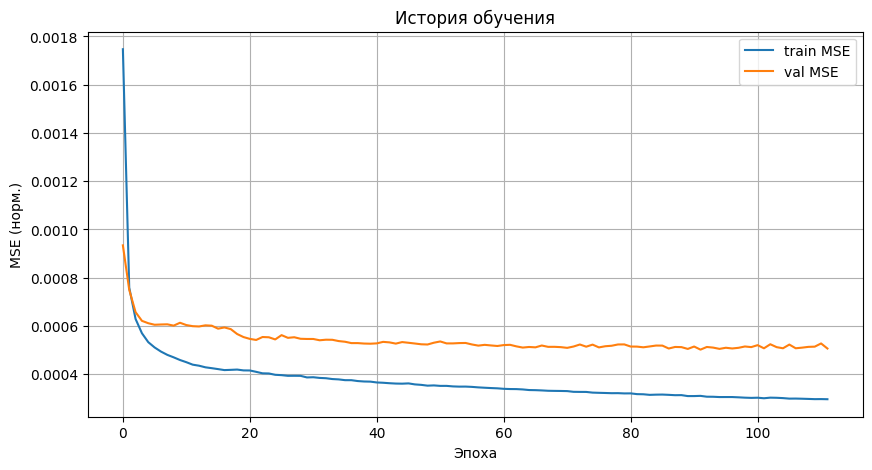

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'],     label='train MSE')
plt.plot(history.history['val_loss'], label='val MSE')
plt.xlabel('Эпоха'); plt.ylabel('MSE (норм.)')
plt.title('История обучения'); plt.legend(); plt.grid(); plt.show()

## 7. Пункт 2 — средний процент ошибки на проверочной выборке

In [ ]:
# Предсказание + обратная нормировка (умножаем обратно на Y_MAX)
pred_val = (model.predict(X_val, verbose=0).ravel() * Y_MAX)

mae_val      = float(np.mean(np.abs(pred_val - y_val)))
mean_price_v = float(y_val.mean())
err_pct_val  = mae_val / mean_price_v * 100

print(f'MAE val          : {mae_val:>12,.0f} руб.')
print(f'Средняя цена val : {mean_price_v:>12,.0f} руб.')
print(f'Процент ошибки   : {err_pct_val:>11.2f}%')

MAE val          :       84,712 руб.
Средняя цена val :      535,294 руб.
Процент ошибки   :       15.83%


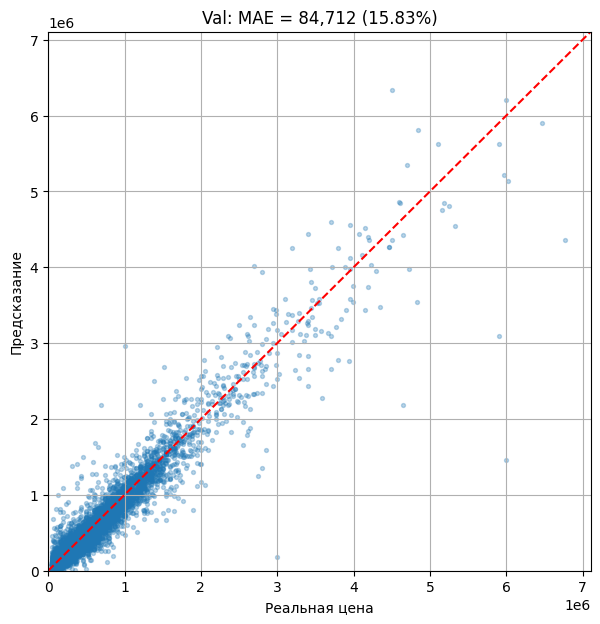

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_val, pred_val, alpha=0.3, s=8)
lim = (0, max(y_val.max(), pred_val.max()) * 1.05)
plt.plot(lim, lim, 'r--')
plt.xlim(lim); plt.ylim(lim)
plt.xlabel('Реальная цена'); plt.ylabel('Предсказание')
plt.title(f'Val: MAE = {mae_val:,.0f} ({err_pct_val:.2f}%)')
plt.grid(); plt.show()

## 8. Пункт 3 — ошибка на каждом примере теста + суммарный % ошибки

In [ ]:
pred_test = (model.predict(X_test, verbose=0).ravel() * Y_MAX)

errors_abs = np.abs(pred_test - y_test)        # модуль ошибки в рублях на каждом примере
errors_pct = errors_abs / y_test * 100         # % ошибки на каждом примере

mae_test     = float(errors_abs.mean())
mean_price_t = float(y_test.mean())
err_pct_test = mae_test / mean_price_t * 100   # ← это и есть «суммарный процент ошибки» из задания

print(f'Размер test               : {len(y_test)}')
print(f'MAE test                  : {mae_test:>12,.0f} руб.')
print(f'Средняя цена test         : {mean_price_t:>12,.0f} руб.')
print(f'СУММАРНЫЙ ПРОЦЕНТ ОШИБКИ  : {err_pct_test:>11.2f}%')

Размер test               : 10289
MAE test                  :       87,730 руб.
Средняя цена test         :      536,994 руб.
СУММАРНЫЙ ПРОЦЕНТ ОШИБКИ  :       16.34%


In [ ]:
# Таблица ошибок по каждому тестовому примеру (это пункт 3 задания)
errors_df = pd.DataFrame({
    'Реальная цена': y_test.astype(int),
    'Предсказание':  pred_test.round(0).astype(int),
    '|Ошибка|':      errors_abs.round(0).astype(int),
    '% ошибки':      errors_pct.round(2),
})
print('Первые 20 примеров теста:')
errors_df.head(20)

Первые 20 примеров теста:


,Реальная цена,Предсказание,|Ошибка|,% ошибки
0,450000,430554,19446,4.320000
1,200000,137996,62004,31.000000
2,1085000,1044796,40204,3.710000
3,310000,339763,29763,9.600000
4,649000,621019,27981,4.310000
5,305000,251776,53224,17.450001
6,425000,423560,1440,0.340000
7,519000,413796,105204,20.270000
8,55000,71642,16642,30.260000
9,357000,358773,1773,0.500000


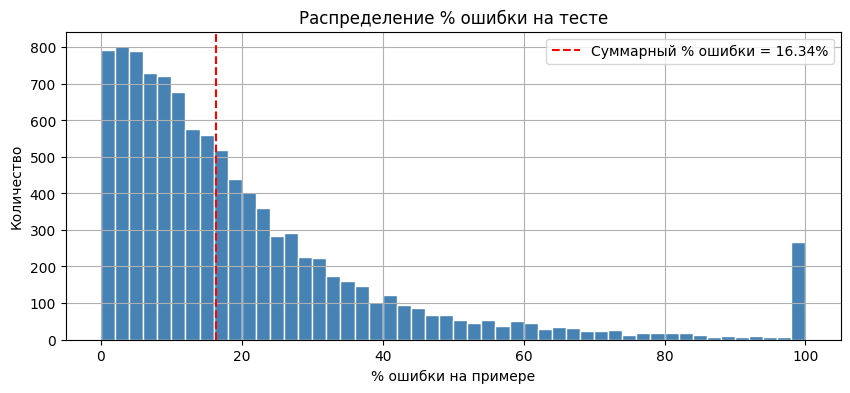

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(np.clip(errors_pct, 0, 100), bins=50, color='steelblue', edgecolor='white')
plt.axvline(err_pct_test, color='red', linestyle='--',
            label=f'Суммарный % ошибки = {err_pct_test:.2f}%')
plt.xlabel('% ошибки на примере'); plt.ylabel('Количество')
plt.title('Распределение % ошибки на тесте'); plt.legend(); plt.grid(); plt.show()